<a href="https://colab.research.google.com/github/luisgogu/cs666student/blob/main/CS666_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

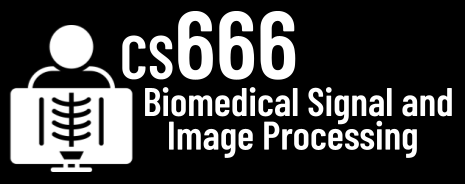

# Assignment 1

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


**Task 1** (5 pts): Install the BioSPPY library with the following code.

In [2]:
!pip install biosppy -q
!pip install peakutils -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 2.0 MB/s eta 0:00:00


**Task 2** (10 pts): Download a sample ecg dataset from https://cs666.org/data/ecg.txt and upload it to this colab. The following code loads the dataset. Note: this might fail with an import error, but should be an easy fix :)

In [4]:
from biosppy import storage
signal, metadata = storage.load_txt('ecg.txt')

**Task 3** (10 pts): Figure out the sampling rate for this data and how many seconds it lasts.

In [6]:
SAMPLING_RATE = metadata['sampling_rate']
SECONDS = len(signal) / SAMPLING_RATE

print(f'Sampling rate: {SAMPLING_RATE} Hz')
print(f'Duration: {SECONDS} seconds')

Sampling rate: 1000.0 Hz
Duration: 15.0 seconds


**Task 4** (15 pts): Process the signal with BioSPPY using the `ecg.ecg` method.

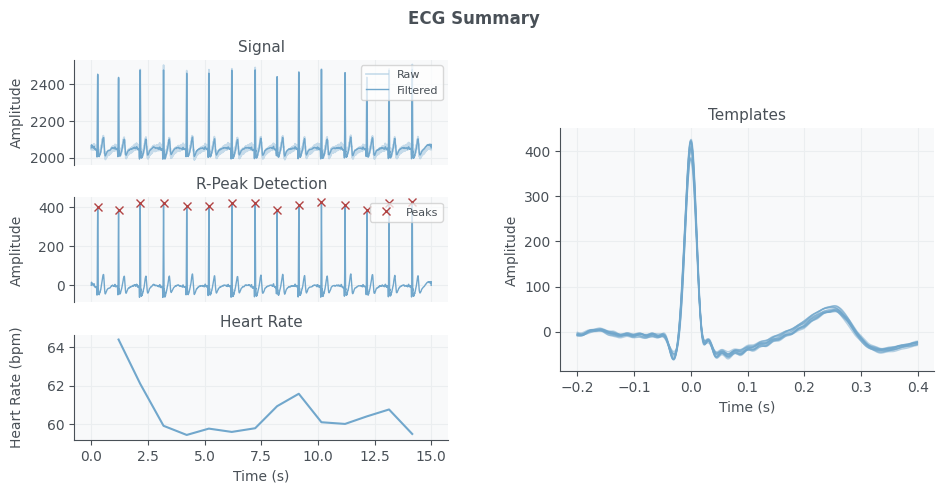

In [7]:
from biosppy.signals import ecg
ecg_summary = ecg.ecg(signal, SAMPLING_RATE, show=True)

**Task 5** (10 pts): Plot the first 3 seconds of the unfiltered signal and then the filtered signal. Can you spot the P, Q, R, S, T waves?

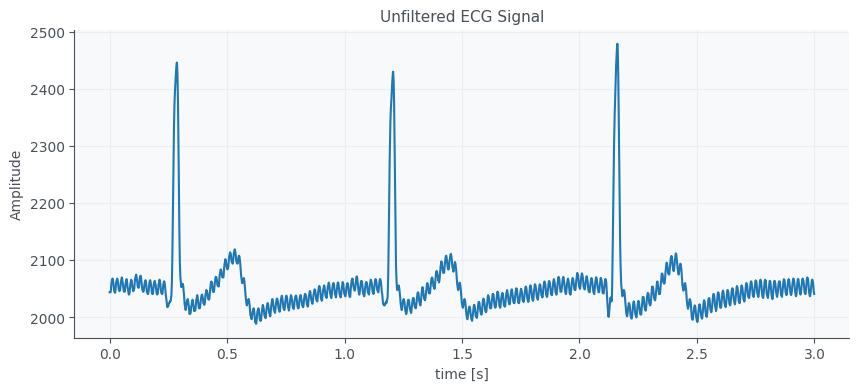

In [8]:
import matplotlib.pyplot as plt
import numpy as np

num_samples = int(3 * SAMPLING_RATE)
time = ecg_summary['ts'][: num_samples]

plt.figure(figsize=(10, 4))
plt.plot(time, signal[:num_samples])
plt.title('Unfiltered ECG Signal')
plt.xlabel('time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

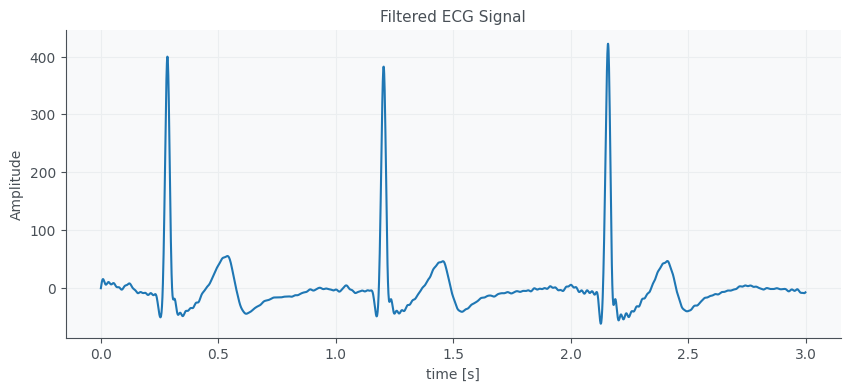

In [9]:
num_samples = int(3 * SAMPLING_RATE)
time = ecg_summary['ts'][: num_samples]

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_summary['filtered'][:num_samples])
plt.title('Filtered ECG Signal')
plt.xlabel('time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

P wave: This is the small, rounded upward deflection occurring just before the large spike. We see them at approximately 0.1s, 1.05s, and 2.0s.

Q wave: The small downward dip immediately preceding the spike
R wave: The tall, sharp peak reaching an amplitude of ~400.
S wave: The sharp downward dip immediately following the R wave peak.

T wave: This is the broader, rounded upward deflection following the QRS complex. These are very clear at roughly 0.5s, 1.4s, and 2.3s.

**Task 6** (15 pts): Please plot the whole filtered signal and mark the r-peaks with vertical lines based on the ecg.ecg output. You can use `plt.axvline(x = 100, color = 'r', ls=':')` to create a red, dashed vertical line at position 100. Please label the x-axis as 'time [s]'.

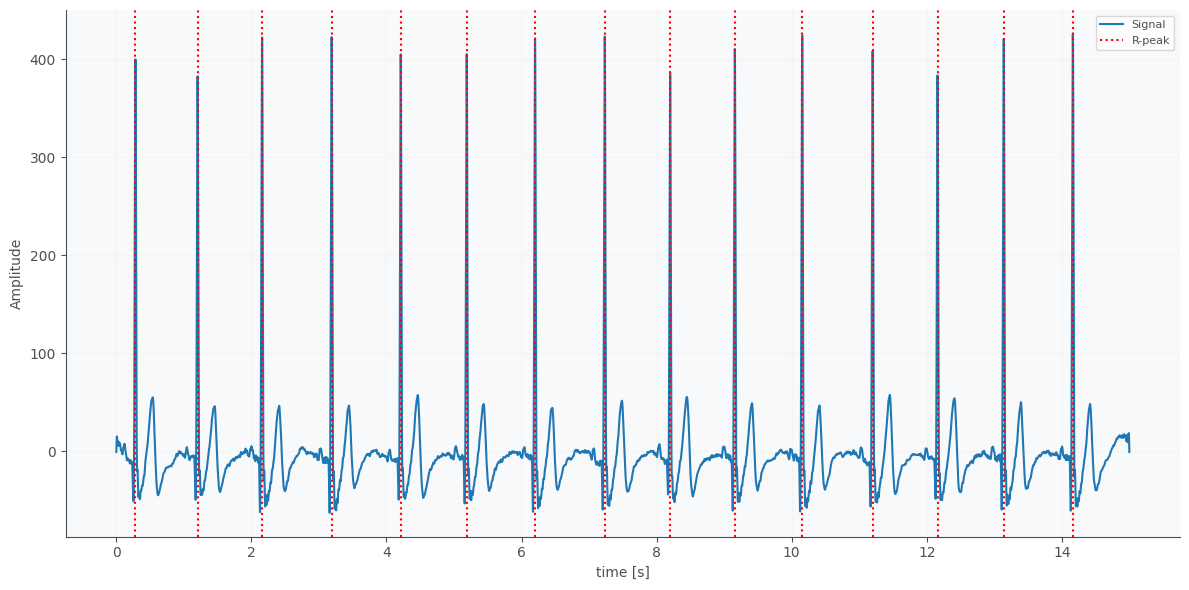

In [10]:
r_peak_indices = ecg_summary['rpeaks']
time = ecg_summary['ts']

plt.figure(figsize=(12, 6))
plt.plot(time, ecg_summary['filtered'], label='Filtered ECG')

for peak_idx in r_peak_indices:
    peak_time = time[peak_idx]
    plt.axvline(x=peak_time, color='r', ls=':')

plt.xlabel('time [s]')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.4)
plt.legend(['Signal', 'R-peak'])
plt.tight_layout()
plt.show()

**Task 7** (5 pts): Let's install the NeuroKit2 library.

In [11]:
!pip install neurokit2 -q
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 7.3 MB/s eta 0:00:00


**Task 8** (20 pts): Detect P Q S T Peaks using Neurokit.

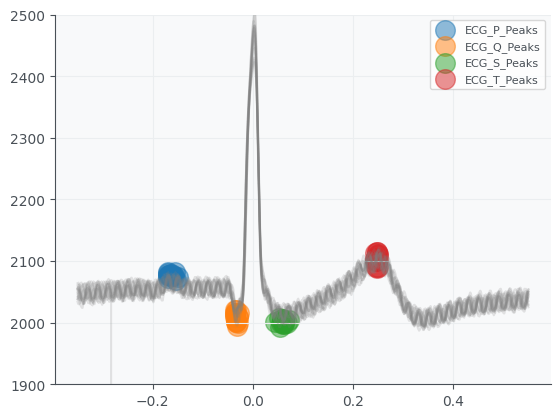

In [26]:
# We know the R spikes now but what about P Q S T waves?
# TODO Can you use nk.ecg_delineate to detect them in the unfiltred signal?
# Hint: Look at the tutorial: https://neuropsychology.github.io/NeuroKit/examples/ecg_delineate/ecg_delineate.html
# Hint 2: The plot will have blue, orange, green, and red circles :)
# Hint 3: rpeaks were detected above from biosppy's ecg.ecg method


_, _ = nk.ecg_delineate(signal,
                        r_peak_indices,
                        sampling_rate=SAMPLING_RATE,
                        method='dwt',
                        show=True)
plt.ylim([1900, 2500])
plt.show()

In [12]:
# TODO Does the detection work well?

We can successfully identify the P-waves (blue) at roughly -0.18s, Q-waves (orange) at -0.05s, S-waves (green) at +0.05s, and T-waves (red) at +0.25s. Although the high-frequency noise in the unfiltered data causes some "jitter" in the circle placements, the algorithm effectively captures the consistent morphology of the heartbeats.

**Task 9** (10 pts): Use the sleepecg library to find the R Peaks.

In [13]:
# We have the R spikes/peaks now from Biosppy from above but there is another
# library called sleepecg.
# TODO Please install it and run the rpeak detection!
# Docs: https://sleepecg.readthedocs.io/en/stable/
!pip install sleepecg -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 3.9 MB/s eta 0:00:00


In [14]:
# TODO Do Biosppy and sleepecg give different rpeaks? Please calculate the MSE!

from sleepecg import detect_heartbeats

rpeaks_sleepecg = detect_heartbeats(signal, fs=SAMPLING_RATE)

print(f"Biosppy peak count: {len(r_peak_indices)}")
print(f"Sleepecg peak count: {len(rpeaks_sleepecg)}")

squared_diffs = (r_peak_indices - rpeaks_sleepecg) ** 2
mse = np.mean(squared_diffs)

print(f"MSE between R-peak indices: {mse}")

Biosppy peak count: 15
Sleepecg peak count: 15
MSE between R-peak indices: 0.2


**Bonus Task** (33 pts): Detect P Q S T Peaks for the full signal before and after filtering.

In [15]:
# TODO As above use the nk.ecg_delineate function to detect peaks for the whole signal
signals_raw, waves_raw = nk.ecg_delineate(signal,
                                r_peak_indices,
                                sampling_rate=SAMPLING_RATE,
                                method="dwt")

In [31]:
import ipywidgets as widgets
from ipywidgets import interact
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt

raw_centered = signal - np.mean(signal)

def plot_filtered_ecg(lowcut, highcut):

    if lowcut >= highcut:
        print("Error: Lowcut frequency must be smaller than Highcut frequency.")
        return

    filtered = nk.signal_filter(signal, sampling_rate=SAMPLING_RATE,
                                lowcut=lowcut, highcut=highcut,
                                method="butterworth")
    plt.figure(figsize=(15, 6))
    plt.plot(raw_centered, color='lightgray', label='Raw Signal (Centered)', alpha=0.6)
    plt.plot(filtered, color='blue', label=f'Filtered ({lowcut}Hz - {highcut}Hz)')

    plt.title(f"ECG Filter Effect: Bandpass {lowcut}-{highcut} Hz")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 3000)
    plt.show()

interact(plot_filtered_ecg,
         lowcut=widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=0.5, description='Lowcut (Hz)'),
         highcut=widgets.IntSlider(min=10, max=100, step=5, value=30, description='Highcut (Hz)'));

interactive(children=(FloatSlider(value=0.5, description='Lowcut (Hz)', max=5.0, min=0.1), IntSlider(value=30,…

In [32]:
# TODO Let's filter the signal and see if the detection improves.
# Hint: You can use nk.signal_filter to define a bandpass.
# Hint 2: Which lowcut and highcut frequencies work well? Play with it :)
# Hint 3: You don't need to re-calculate the rpeaks since they are pretty accurate in general.

signal_filtered = nk.signal_filter(signal,
                                  sampling_rate=SAMPLING_RATE,
                                  lowcut=0.5,
                                  highcut=20,
                                  method="butterworth")

signals_filtered, waves_filtered = nk.ecg_delineate(signal_filtered,
                               r_peak_indices,
                               sampling_rate=SAMPLING_RATE,
                               method="dwt")

In [33]:
# Finally, run the delineation on the filtered signal from BioSPPY.
signals_biosspy, waves_biosppy = nk.ecg_delineate(ecg_summary['filtered'],
                                        r_peak_indices,
                                        sampling_rate=SAMPLING_RATE,
                                        method="dwt")

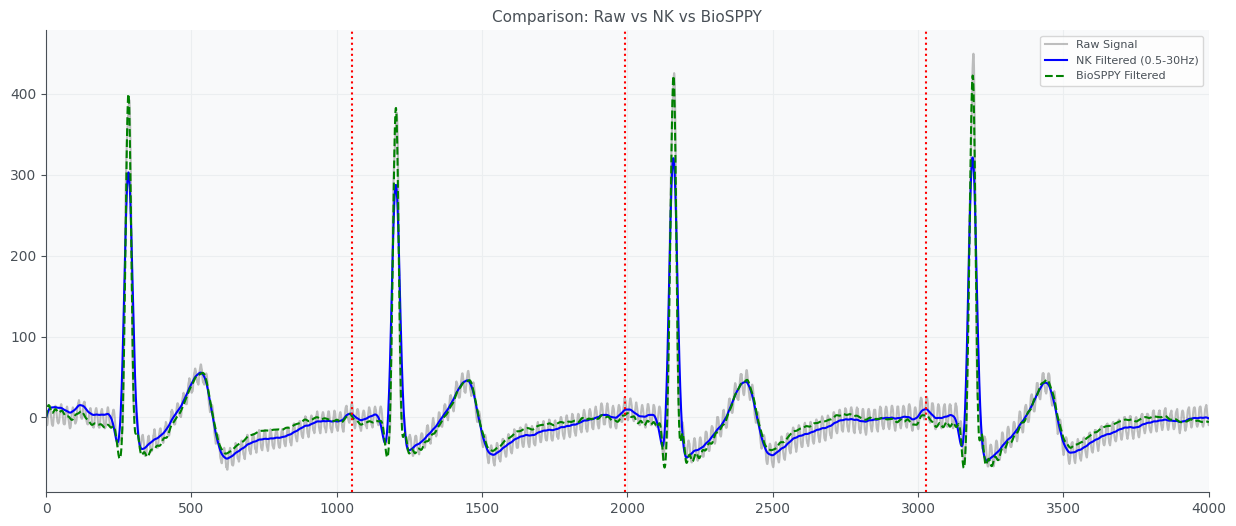

In [34]:
# TODO Which one works the best?
plt.figure(figsize=(15, 6))

plt.plot(signal - np.mean(signal), label='Raw Signal', alpha=0.5, color='gray')
plt.plot(signal_filtered, label='NK Filtered (0.5-20Hz)', color='blue')
plt.plot(ecg_summary['filtered'], label='BioSPPY Filtered', color='green', linestyle='--')

for p in waves_raw['ECG_P_Peaks']:
    plt.axvline(x=p, color='red', linestyle=':')

plt.title("Comparison: Raw vs NK vs BioSPPY")
plt.legend()
plt.xlim(0,4000)
plt.show()

Based on the visual comparison we can conclude that the NeuroKit2 filtered signal shows the best result. While the raw signal suffers from significant high-frequency noise, the NK filter (using a 0.5Hz-20Hz bandpass) effectively removes these artifacts. Compared to Biosspy filtered signal, the NK signal shows a better fit to the underlying trend of the raw ECG, at least with the current parameter values.

In [ ]:
#
# Great job!!
#
#  , ; ,   .-'"""'-.   , ; ,
#  \\|/  .'         '.  \|//
#   \-;-/   ()   ()   \-;-/
#   // ;               ; \\
#  //__; :.         .; ;__\\
# `-----\'.'-.....-'.'/-----'
#        '.'.-.-,_.'.'
#jgs       '(  (..-'
#            '-'
#